In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask


from firedrake import *
from firedrake.__future__ import interpolate

### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *

%matplotlib widget

# Just run on the coarse mesh for now

In [2]:
### Create the mesh ###

coarse_bed_path = "../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif"
coarse_surf_path = "../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif"
coarse_resamp_factor=1/200
layers = 5

mesh = mesh_creator(coarse_bed_path, coarse_surf_path, resamp_factor=coarse_resamp_factor, layers=layers)
x_src, y_src, z_src = SpatialCoordinate(mesh)

In [3]:
### Run the flow model ###

flow, Y = scripts.model_modules.run_flow_model(mesh)

# Plot a cross sections

In [4]:
flowline_surf = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC2302_surface_rema_100m.csv')
flowline_bed = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC2302_bed_merged_100m.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

z_coords = np.linspace(1300, 2200, 30)

In [5]:
vel_prof=[]
u_prof = []
v_prof = []
z_prof = []
vel_prof_coords = []

distance = 0
for n in range(len(flowline_xs)):

    for z_coord in z_coords:
        try:
            velocity = flow.at(flowline_xs[n], flowline_ys[n], z_coord)[0]*spy
            vel_prof.append(velocity)
            u_prof.append(velocity[0])
            v_prof.append(velocity[1])
            z_prof.append(velocity[2])
            distance = flowline_distance[n]
            vel_prof_coords.append([distance, z_coord])

        except:
            continue

vel_prof=np.array(vel_prof)
u_prof = np.array(u_prof)
v_prof = np.array(v_prof)
z_prof = np.array(z_prof)
vel_prof_coords = np.array(vel_prof_coords)

In [6]:
### sample the DEM directly
src_bed_resampled = rasterio.open("resampled_meshes/resampled_bed_dem.tif")
coords_flowline = [(x,y) for x,y in zip(flowline_xs, flowline_ys)]
bed_along_flowline_from_tiff_resamp = [x for x in src_bed_resampled.sample(coords_flowline)]
bed_along_flowline_from_tiff_resamp = np.array(bed_along_flowline_from_tiff_resamp)


### sample the DEM directly
src_bed_full = rasterio.open("../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif")
bed_along_flowline_from_tiff_full = [x for x in src_bed_full.sample(coords_flowline)]
bed_along_flowline_from_tiff_full = np.array(bed_along_flowline_from_tiff_full)

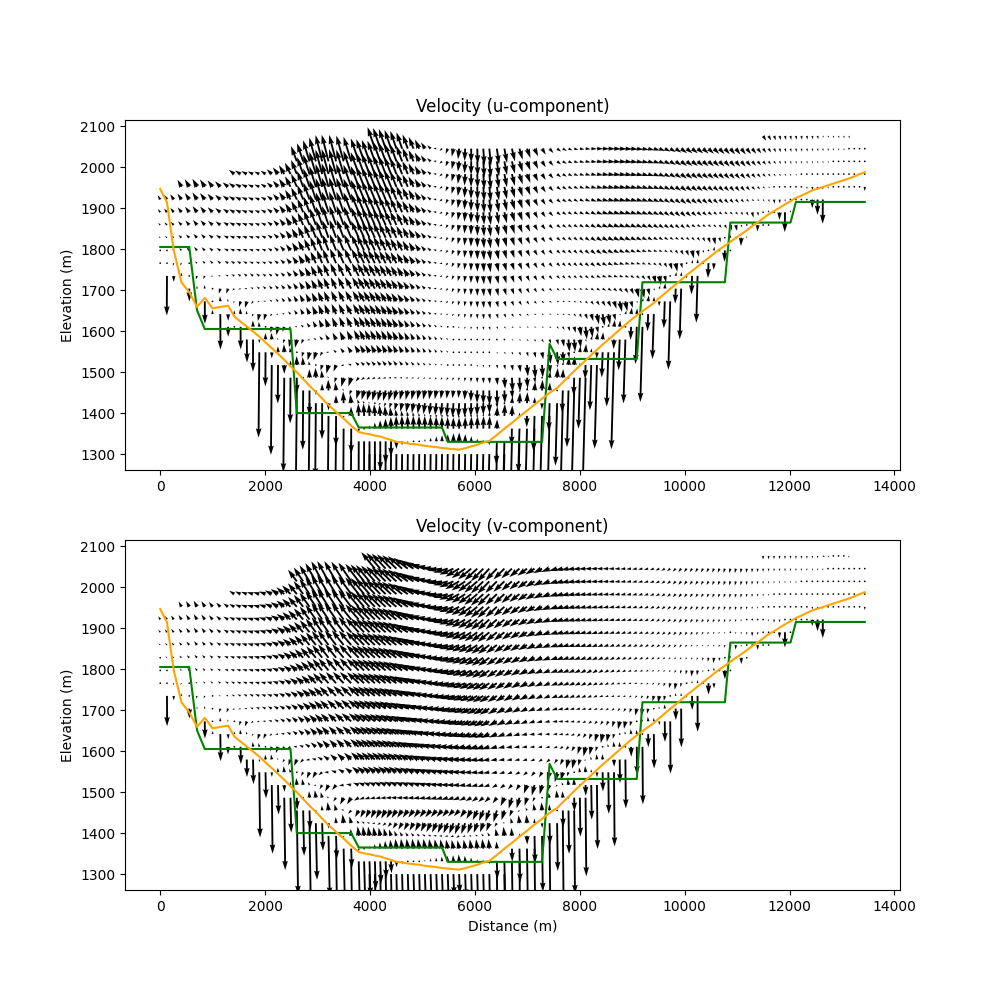

In [7]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=[10,10])

ax1.quiver(vel_prof_coords[:,0], vel_prof_coords[:,1], u_prof, z_prof,angles='xy', scale_units='xy', scale=None,)
ax2.quiver(vel_prof_coords[:,0], vel_prof_coords[:,1], v_prof, z_prof,angles='xy', scale_units='xy', scale=None,)
ax1.set_ylabel('Elevation (m)')
ax2.set_ylabel('Elevation (m)')

ax2.set_xlabel('Distance (m)')

ax1.set_title('Velocity (u-component)')
ax2.set_title('Velocity (v-component)')

ax1.plot(flowline_distance.values,bed_along_flowline_from_tiff_resamp, c='green', label='Bed Profile - from DEM directly, resampled')
ax1.plot(flowline_distance.values,bed_along_flowline_from_tiff_full, c='orange', label='Bed Profile - from DEM directly, full')

ax2.plot(flowline_distance.values,bed_along_flowline_from_tiff_resamp, c='green', label='Bed Profile - from DEM directly, resampled')
ax2.plot(flowline_distance.values,bed_along_flowline_from_tiff_full, c='orange', label='Bed Profile - from DEM directly, full')


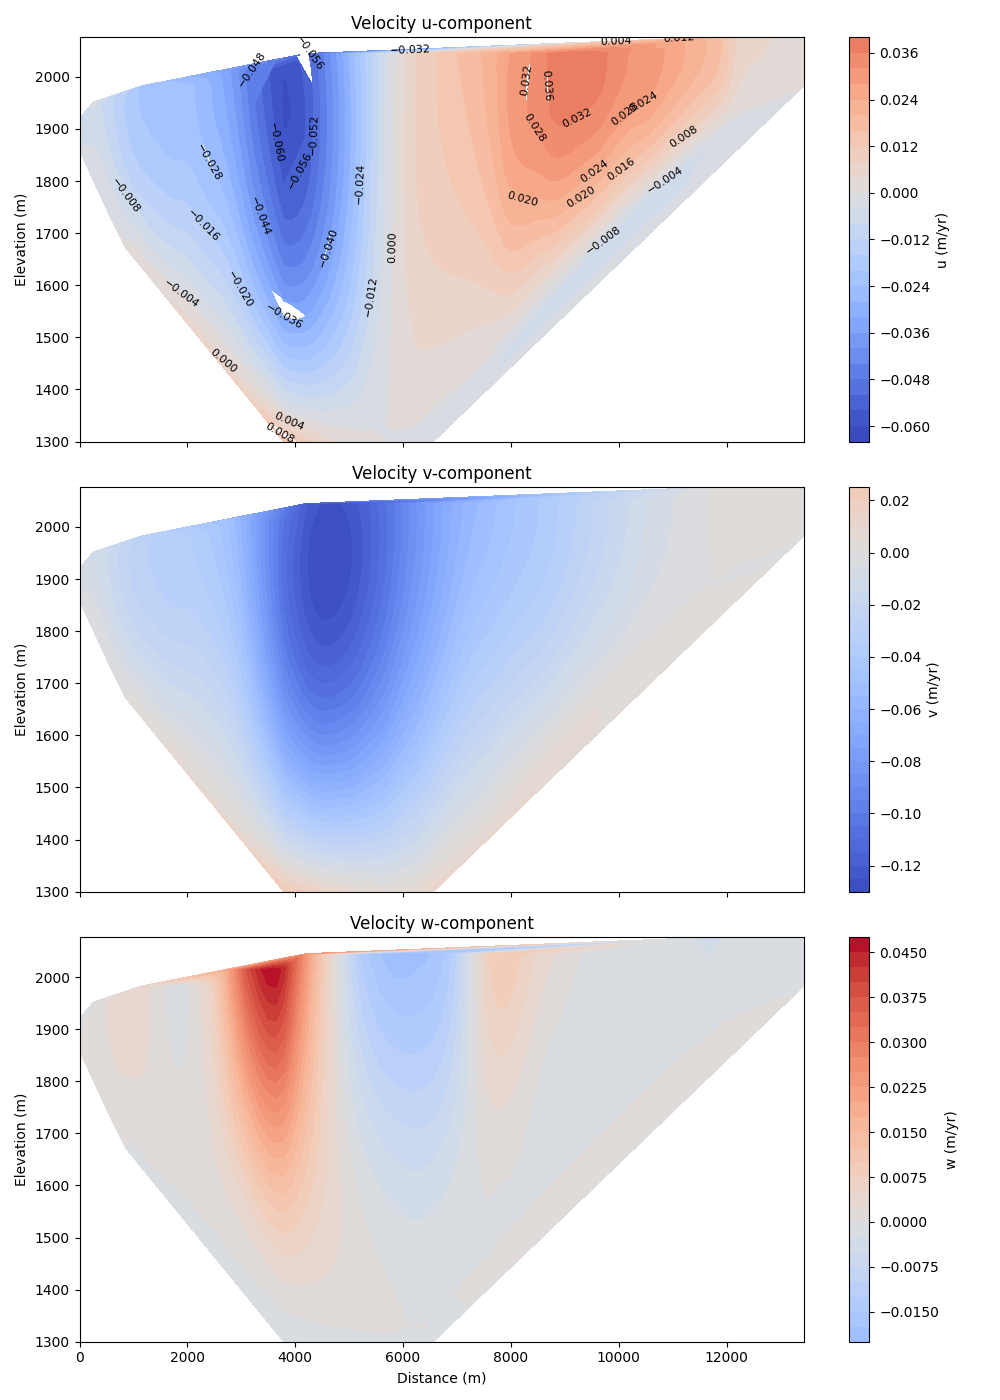

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(10, 14), sharex=True
)

x = vel_prof_coords[:, 0]   # distance
z = vel_prof_coords[:, 1]   # elevation

levels = 30  # increase for smoother contours

vm = np.max(np.abs(u_prof))
cu = ax1.tricontourf(x, z, u_prof, levels=levels,vmin=-vm,vmax=vm, cmap='coolwarm')
vm = np.max(np.abs(v_prof))
cv = ax2.tricontourf(x, z, v_prof, levels=levels,vmin=-vm,vmax=vm, cmap='coolwarm')
vm = np.max(np.abs(z_prof))
cw = ax3.tricontourf(x, z, z_prof, levels=levels,vmin=-vm,vmax=vm, cmap='coolwarm')

plt.clabel(cu, inline = True, fontsize=8, colors = 'black')

# ax1.tricontourf(x, z, u_prof,colors = '-k')
# ax2.tricontourf(x, z, v_prof,colors = '-k')
# ax3.tricontourf(x, z, z_prof,colors = '-k')

# Labels
ax1.set_title('Velocity u-component')
ax2.set_title('Velocity v-component')
ax3.set_title('Velocity w-component')

ax3.set_xlabel('Distance (m)')
ax1.set_ylabel('Elevation (m)')
ax2.set_ylabel('Elevation (m)')
ax3.set_ylabel('Elevation (m)')

# Optional: invert elevation if depth-like
# ax1.invert_yaxis()
# ax2.invert_yaxis()
# ax3.invert_yaxis()

# Colorbars
fig.colorbar(cu, ax=ax1, label='u (m/yr)')
fig.colorbar(cv, ax=ax2, label='v (m/yr)')
fig.colorbar(cw, ax=ax3, label='w (m/yr)')

plt.tight_layout()


# Test different number of mesh layers to see if it changes how the boundary conditions are applied

In [2]:

flowline_surf = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC2302_surface_rema_100m.csv')
flowline_bed = pd.read_csv('../flowlines/manual_flowlines/csv/ALHIC2302_bed_merged_100m.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

z_coords = np.linspace(1300, 2200, 500) 

### sample the DEM directly
src_bed_resampled = rasterio.open("resampled_meshes/resampled_bed_dem.tif")
coords_flowline = [(x,y) for x,y in zip(flowline_xs, flowline_ys)]
bed_along_flowline_from_tiff_resamp = [x for x in src_bed_resampled.sample(coords_flowline)]
bed_along_flowline_from_tiff_resamp = np.array(bed_along_flowline_from_tiff_resamp)


### sample the DEM directly
src_bed_full = rasterio.open("../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif")
bed_along_flowline_from_tiff_full = [x for x in src_bed_full.sample(coords_flowline)]
bed_along_flowline_from_tiff_full = np.array(bed_along_flowline_from_tiff_full)

### import the boreholes ###

### Load boreholes
borehole_locations = pd.read_csv('../Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### On a flowline

In [ ]:
### Create the mesh ###
fig, axes = plt.subplots(3, 1)
coarse_bed_path = "../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif"
coarse_surf_path = "../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif"
coarse_resamp_factor=1/300

for ax, layer_num in zip(axes, [5, 10, 30]):

    mesh = mesh_creator(coarse_bed_path, coarse_surf_path, resamp_factor=coarse_resamp_factor, layers=layer_num)
    x_src, y_src, z_src = SpatialCoordinate(mesh)


    flow, Y = scripts.model_modules.run_flow_model(mesh)

    vel_prof=[]
    u_prof = []
    v_prof = []
    z_prof = []
    vel_prof_coords = []

    distance = 0
    for n in range(len(flowline_xs)):

        for z_coord in z_coords:
            try:
                velocity = flow.at(flowline_xs[n], flowline_ys[n], z_coord)[0]*spy
                vel_prof.append(velocity)
                u_prof.append(velocity[0])
                v_prof.append(velocity[1])
                z_prof.append(velocity[2])
                distance = flowline_distance[n]
                vel_prof_coords.append([distance, z_coord])

            except:
                continue

    vel_prof=np.array(vel_prof)
    u_prof = np.array(u_prof)
    v_prof = np.array(v_prof)
    z_prof = np.array(z_prof)
    vel_prof_coords = np.array(vel_prof_coords)


    vm = np.max(np.abs(u_prof))
    cu = ax.tricontourf(vel_prof_coords[:,0], vel_prof_coords[:,1], u_prof, levels=30,vmin=-vm,vmax=vm, cmap='coolwarm')
    ax.quiver(vel_prof_coords[:,0], vel_prof_coords[:,1], u_prof, z_prof,angles='xy', scale_units='xy', scale=None,minlength=10)
    # Colorbars
    fig.colorbar(cu, ax=ax, label='u (m/yr)')
    ax.plot(flowline_distance.values,bed_along_flowline_from_tiff_resamp, c='green', label='Bed Profile - from DEM directly, resampled')
    ax.plot(flowline_distance.values,bed_along_flowline_from_tiff_full, c='orange', label='Bed Profile - from DEM directly, full')

### At a single borehole

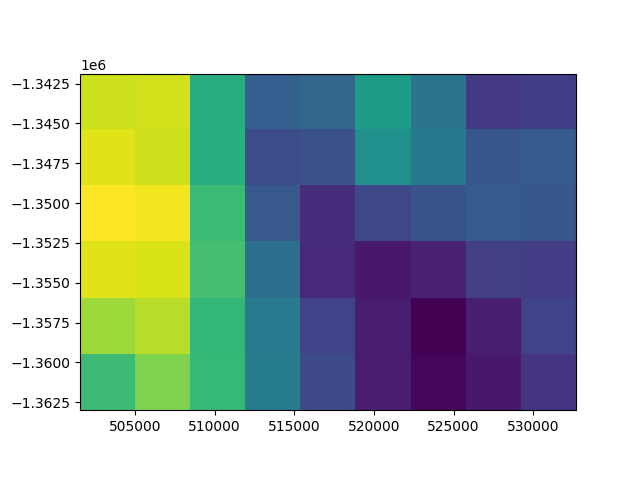

In [37]:
mesh_bed_dem = rasterio.open('bed_dem_resamped_test.tif')
fig,ax=plt.subplots()
show(mesh_bed_dem)
ax.scatter(x_coord[0], y_coord[0])

/usr/local/lib/python3.12/dist-packages/pyproj/transformer.py:817: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return self._transformer._transform_point(


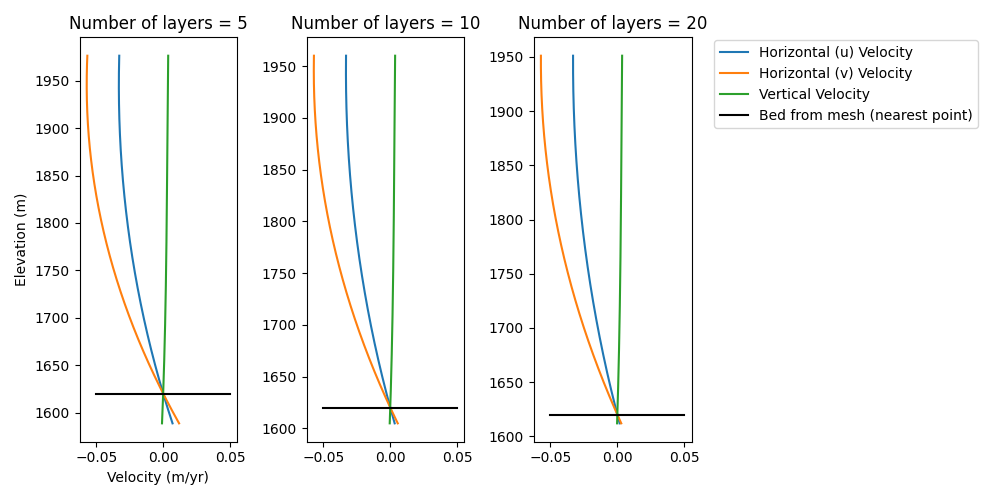

In [19]:
### Create the mesh ###
fig, axes = plt.subplots(1, 3, figsize=[10,5])
coarse_bed_path = "../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif"
coarse_surf_path = "../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif"
coarse_resamp_factor=1/300

borehole = borehole_locations.loc[borehole_locations['Core']=='ALHIC1901']
x_coord, y_coord = transformer.transform(borehole['E'], borehole['S'])
mesh_bed_dem = rasterio.open('bed_dem_resamped_test.tif')

for ax, layer_num in zip(axes, [5, 10, 20]):

    mesh = mesh_creator(coarse_bed_path, coarse_surf_path, resamp_factor=coarse_resamp_factor, layers=layer_num)
    x_src, y_src, z_src = SpatialCoordinate(mesh)


    flow, Y = scripts.model_modules.run_flow_model(mesh)

    vel_prof=[]
    u_prof = []
    v_prof = []
    z_prof = []
    vel_prof_coords = []


    x_coords_mesh, y_coords_mesh = np.unique(mesh.coordinates.dat.data_ro[:,0]), np.unique(mesh.coordinates.dat.data_ro[:,1])
    bed_of_mesh_coords = []
    for x_co in x_coords_mesh:
        for y_co in y_coords_mesh:
            z_s =[]
            for x,y,z in zip(mesh.coordinates.dat.data_ro[:,0], mesh.coordinates.dat.data_ro[:,1], mesh.coordinates.dat.data_ro[:,2]):

                if (x_co, y_co) == (x,y):
                    z_s.append(z)

            z_min = np.array(z_s).min()

            bed_of_mesh_coords.append((x_co, y_co, z_min))

    bed_of_mesh_coords_arr = np.array(bed_of_mesh_coords)
    low_val = np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-x_coord)**2 + (bed_of_mesh_coords_arr[:,1]-y_coord)**2))
    z_in_mesh_nearest = bed_of_mesh_coords_arr[:,2][low_val]
    x_in_mesh_nearest, y_in_mesh_nearest = bed_of_mesh_coords_arr[:,0][low_val], bed_of_mesh_coords_arr[:,1][low_val]

    for z_coord in z_coords:
        try:
            velocity = flow.at(x_in_mesh_nearest, y_in_mesh_nearest, z_coord)[0]*spy
            vel_prof.append(velocity)
            u_prof.append(velocity[0])
            v_prof.append(velocity[1])
            z_prof.append(velocity[2])
            vel_prof_coords.append(z_coord)

        except:
            continue

    vel_prof=np.array(vel_prof)
    u_prof = np.array(u_prof)
    v_prof = np.array(v_prof)
    z_prof = np.array(z_prof)
    vel_prof_coords = np.array(vel_prof_coords)

    ax.plot(u_prof, vel_prof_coords, label='Horizontal (u) Velocity')
    ax.plot(v_prof, vel_prof_coords, label='Horizontal (v) Velocity')
    ax.plot(z_prof, vel_prof_coords, label='Vertical Velocity')
    ax.set_title('Number of layers = '+str(layer_num))
    # ax.set_ylim([1610,1650])


    ax.plot([-0.05,0.05],[z_in_mesh_nearest, z_in_mesh_nearest], '-k', label='Bed from mesh (nearest point)')
ax.legend(bbox_to_anchor=(1.1, 1.01))

axes[0].set_ylabel('Elevation (m)')
axes[0].set_xlabel('Velocity (m/yr)')

plt.tight_layout()

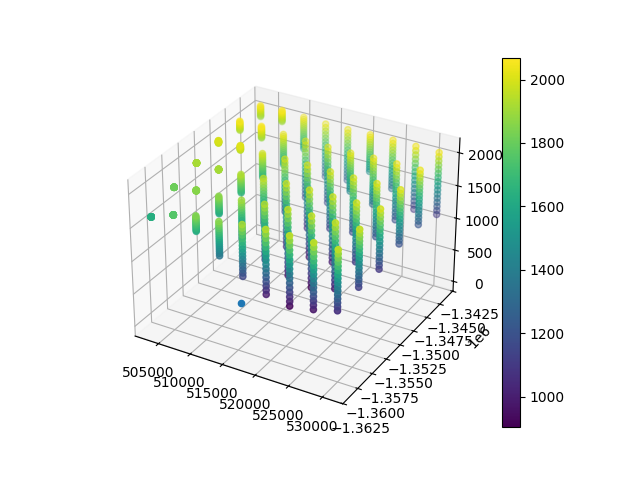

In [74]:


ax = plt.figure().add_subplot(projection='3d')
im = ax.scatter(mesh.coordinates.dat.data_ro[:,0], mesh.coordinates.dat.data_ro[:,1], mesh.coordinates.dat.data_ro[:,2],c=mesh.coordinates.dat.data_ro[:,2])
cbar = plt.colorbar(im,ax=ax)

ax.scatter(x_coord[0], y_coord[0])

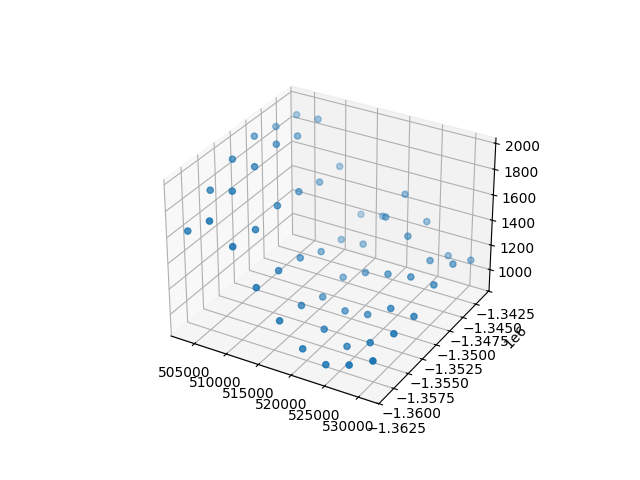

In [8]:
bed_of_mesh_coords_arr = np.array(bed_of_mesh_coords)

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(bed_of_mesh_coords_arr[:,0], bed_of_mesh_coords_arr[:,1], bed_of_mesh_coords_arr[:,2])

In [12]:
np.argmin(np.sqrt((bed_of_mesh_coords_arr[:,0]-x_coord)**2 + (bed_of_mesh_coords_arr[:,1]-y_coord)**2))

np.int64(14)

In [9]:
x_coord

array([510423.76218009])

In [65]:
src_bed_path = "../Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif"
src_surf_path = "../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif"
resamp_factor=1/400

src_bed = rasterio.open(src_bed_path)
src_surf = rasterio.open(src_surf_path)

bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * resamp_factor),
                            int(src_bed.width * resamp_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)


# src_surf = rasterio.open("../Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * resamp_factor),
                            int(src_surf.width * resamp_factor)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###

thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]

In [14]:
src_bed.profile

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': -10000.0, 'width': 3892, 'height': 2637, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Antarctic Polar Stereographic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",-71],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",NORTH],AXIS["Northing",NORTH],AUTHORITY["EPSG","3031"]]'), 'transform': Affine(8.0, 0.0, 501550.1993,
       0.0, -8.0, -1341916.8646), 'blockxsize': 3892, 'blockysize': 1, 'tiled': False, 'interleave': 'band'}

In [15]:
with rasterio.Env():

    # Write an array as a raster band to a new 8-bit file. For
    # the new file's profile, we start with the profile of the source
    profile = src_bed.profile

    # And then change the band count to 1, set the
    # dtype to uint8, and specify LZW compression.
    profile.update(
        count=1,
        compress='lzw',
        transform=src_bed_transform,
        height=height,
        width=width)

    with rasterio.open('bed_dem_resamped_test.tif', 'w', **profile) as dst:
        dst.write(bed_DEM, 1)

# At the end of the ``with rasterio.Env()`` block, context
# manager exits and all drivers are de-registered.

NameError: name 'x_coord' is not defined

In [8]:
plt.savefig('bc_testing.png', dpi=300)

# Save the mesh to visualize later

In [45]:
# File("mesh/coarse_mesh_v1.pvd").write(mesh)